In [22]:
import time
import pandas as pd
from scipy.sparse import load_npz, hstack, csr_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import SVC

X_train_tfidf = load_npz('datasets/X_train.npz')
X_test_tfidf = load_npz('datasets/X_test.npz')

X_train_extra = pd.read_csv('datasets/X_extra_train.csv').astype(float)
X_test_extra = pd.read_csv('datasets/X_extra_test.csv').astype(float)

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

X_train = hstack([X_train_tfidf, csr_matrix(X_train_extra.values)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_extra.values)])

svc_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)

start_train = time.time()
svc_model.fit(X_train, y_train)
train_duration = time.time() - start_train

start_pred = time.time()
y_pred = svc_model.predict(X_test)
predict_duration = time.time() - start_pred

print(f"Training duration: {train_duration:.4f}")
print(f"Predict duration: {predict_duration:.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Training duration: 96.7432
Predict duration: 4.5518
Accuracy: 0.9802
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      1977
           1       0.97      0.98      0.97      1209

    accuracy                           0.98      3186
   macro avg       0.98      0.98      0.98      3186
weighted avg       0.98      0.98      0.98      3186



------------
#### Análisis matriz de confusión

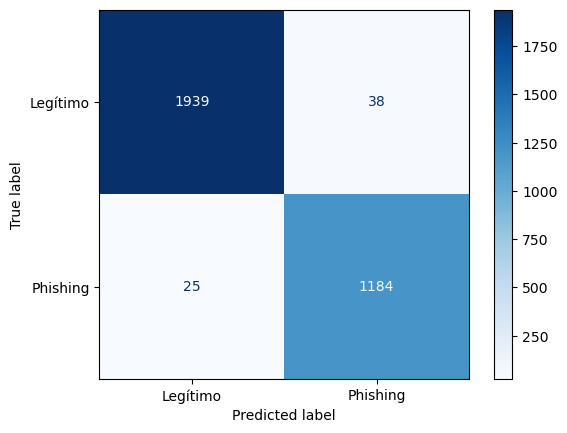

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

----------
#### Curva Roc

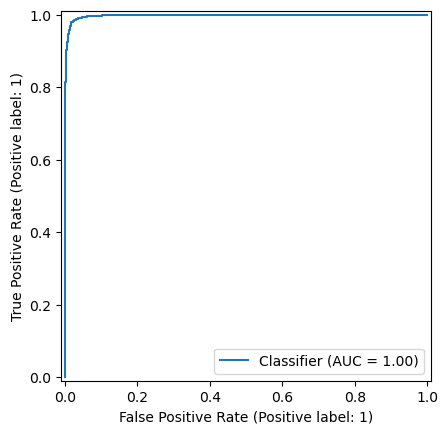

In [24]:
from sklearn.metrics import RocCurveDisplay
y_scores = svc_model.predict_proba(X_test)[:, 1]  # o svc_model.decision_function(X_test) si no usaste probability=True
RocCurveDisplay.from_predictions(y_test, y_scores)

-----------
#### Vectores de soporte por clase

<BarContainer object of 2 artists>

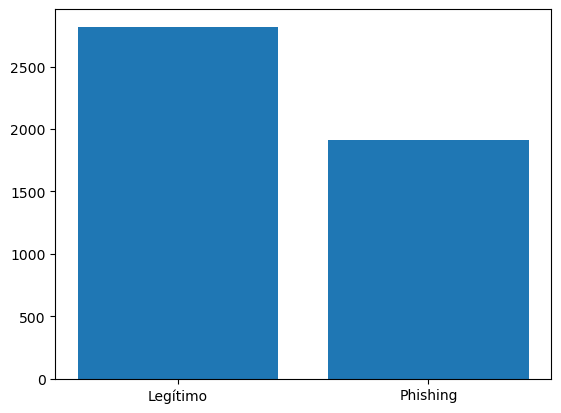

In [26]:
import matplotlib.pyplot as plt
plt.bar(['Legítimo', 'Phishing'], svc_model.n_support_)